5장 컴퓨터 비전

In [1]:
# 예제 5.1 이미지 분류 CNN 모델(CIFAR-10)

# 셋업
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 디바이스 지정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# CIFAR10 학습 데이터의 RGB 평균/표준편차 확인
dataset = datasets.CIFAR10(root="./data", train=True, download=True)

data = dataset.data / 255.0   # 정규화(0 ~ 1)
mean = data.mean(axis=(0, 1, 2))   # 평균 계산
std = data.std(axis=(0, 1, 2))   # 표준편차 계산

print(f"mean: {mean.round(2)} \n std: {std.round(2)}")

In [12]:
# 데이터셋 준비/전처리
transform = transforms.Compose([
    transforms.ToTensor(),   # 텐서 변환
    transforms.Normalize((0.49, 0.48, 0.45), (0.25, 0.24, 0.26))   # 정규화
])

train_dataset = datasets.CIFAR10(root="./data", train=True,
                                 download=True, transform=transform)

test_dataset = datasets.CIFAR10(root="./data", train=False,
                                download=True, transform=transform)

print(train_dataset.data.shape)  # 학습 데이터 shape 확인
print(test_dataset.data.shape)  # 테스트 데이터 shape 확인

(50000, 32, 32, 3)
(10000, 32, 32, 3)


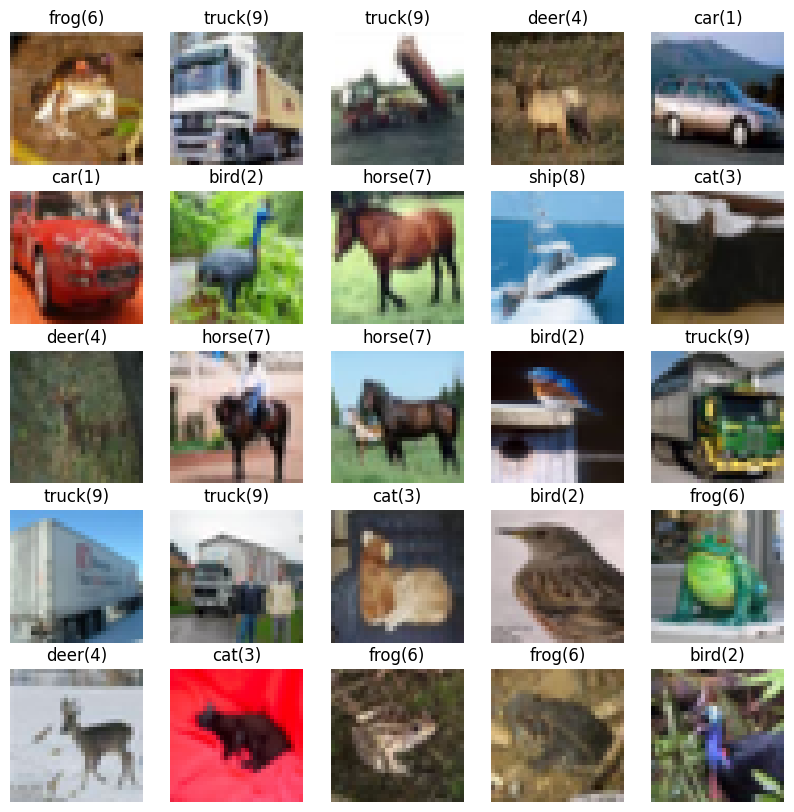

In [ ]:
# 학습 데이터 시각화
class_names = ["plane", "car", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

mean = torch.tensor([0.49, 0.48, 0.45]).view(3,1,1)
std = torch.tensor([0.25, 0.24, 0.26]).view(3,1,1)

plt.figure(figsize=(10, 10))

for i in range(25):
    image, label = train_dataset[i]
    image = image * std + mean   # 역정규화

    plt.subplot(5, 5, i + 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(f"{class_names[label]}({label})")
    plt.axis("off")

plt.show()

In [13]:
# 학습 데이터/검증 데이터 분할
train_size = int(0.8 * len(train_dataset))
valid_size = len(train_dataset) - train_size

train_dataset, valid_dataset = random_split(
    train_dataset, [train_size, valid_size])

In [14]:
# 데이터 로더 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [15]:
# 모델 생성
class CIFAR10Model(nn.Module):
    def __init__(self):
        super().__init__()

        # 특징 추출 신경망
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # 분류 신경망
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

model = CIFAR10Model().to(device)

In [ ]:
# 모델 확인
print(model)   # model._modules

CIFAR10Model(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1),

In [ ]:
# torchinfo 설치
!pip install torchinfo

In [ ]:
# 모델 구조 요약
from torchinfo import summary

summary(model, input_size=(1, 3, 32, 32))  # 배치 크기 1, 입력(32x32x3)

Layer (type:depth-idx)                   Output Shape              Param #
CIFAR10Model                             [1, 10]                   --
├─Sequential: 1-1                        [1, 128, 4, 4]            --
│    └─Conv2d: 2-1                       [1, 32, 32, 32]           896
│    └─BatchNorm2d: 2-2                  [1, 32, 32, 32]           64
│    └─ReLU: 2-3                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-4                       [1, 32, 32, 32]           9,248
│    └─BatchNorm2d: 2-5                  [1, 32, 32, 32]           64
│    └─ReLU: 2-6                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-7                    [1, 32, 16, 16]           --
│    └─Conv2d: 2-8                       [1, 64, 16, 16]           18,496
│    └─BatchNorm2d: 2-9                  [1, 64, 16, 16]           128
│    └─ReLU: 2-10                        [1, 64, 16, 16]           --
│    └─Conv2d: 2-11                      [1, 64, 16, 16]           36,928
│ 

In [16]:
# 하이퍼파라미터 설정
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [17]:
# 학습 함수 정의
def train_step(model, optimizer, loss_fn, train_loader, device):
    model.train()   # 학습 모드

    train_loss = 0
    correct = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)   # 출력 계산
        loss = loss_fn(outputs, labels)   # 손실 계산

        optimizer.zero_grad()   # 그레디언트 초기화
        loss.backward()   # 역전파
        optimizer.step()   # 최적화 수행

        train_loss += loss.item() * images.size(0)

        predict = outputs.argmax(dim=1)   # 예측
        correct += (predict == labels).sum().item()   # 정확한 예측

    train_loss /= len(train_loader.dataset)   # 학습 손실
    train_acc = correct / len(train_loader.dataset)   # 학습 정확도

    return train_loss, train_acc

In [18]:
# 검증 함수 정의
def validation_step(model, loss_fn, valid_loader, device):
    model.eval()   # 평가 모드

    valid_loss = 0
    correct = 0

    with torch.no_grad():   # 검증할 때에는 자동 미분하지 않음
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)   # 출력 계산
            loss = loss_fn(outputs, labels)   # 손실 계산

            valid_loss += loss.item() * images.size(0)

            predict = outputs.argmax(dim=1)   # 예측
            correct += (predict == labels).sum().item()   # 정확한 예측

    valid_loss /= len(valid_loader.dataset)   # 검증 손실
    valid_acc = correct / len(valid_loader.dataset)   # 검증 정확도

    return valid_loss, valid_acc

In [19]:
# 모델 학습
epochs = 50   # 반복 횟수

patience = 3   # 조기 종료 조건
best_loss = np.inf   # 초기 손실값
counter = 0

train_losses = []   # 학습 손실 리스트
train_accs = []   # 학습 정확도 리스트
valid_losses = []   # 검증 손실 리스트
valid_accs = []   # 검증 정확도 리스트

for epoch in range(epochs):
    train_loss, train_acc = train_step(model, optimizer, loss_fn, train_loader, device)
    train_losses.append(train_loss)   # 학습 손실 저장
    train_accs.append(train_acc)   # 학습 정확도 저장

    valid_loss, valid_acc = validation_step(model, loss_fn, valid_loader, device)
    valid_losses.append(valid_loss)   # 검증 손실 저장
    valid_accs.append(valid_acc)   # 검증 정확도 저장

    if valid_loss < best_loss:   # 조기 종료 검사
        best_loss = valid_loss
        counter = 0
    else:
        counter += 1

        if counter == patience:
            break

    print(f"Epoch {epoch + 1} / {epochs} \n"
          f" - loss: {train_loss:.4f}  - accuracy: {train_acc:.4f}"
          f"  - val_loss: {valid_loss:.4f}  - val_accuracy: {valid_acc:.4f}")

Epoch 1 / 50 
 - loss: 1.5890  - accuracy: 0.4147  - val_loss: 1.1713  - val_accuracy: 0.5832
Epoch 2 / 50 
 - loss: 1.2535  - accuracy: 0.5488  - val_loss: 0.9793  - val_accuracy: 0.6456
Epoch 3 / 50 
 - loss: 1.1084  - accuracy: 0.6048  - val_loss: 0.8741  - val_accuracy: 0.6807
Epoch 4 / 50 
 - loss: 1.0169  - accuracy: 0.6421  - val_loss: 0.8186  - val_accuracy: 0.7077
Epoch 5 / 50 
 - loss: 0.9430  - accuracy: 0.6686  - val_loss: 0.8067  - val_accuracy: 0.7165
Epoch 6 / 50 
 - loss: 0.8857  - accuracy: 0.6912  - val_loss: 0.7163  - val_accuracy: 0.7507
Epoch 7 / 50 
 - loss: 0.8368  - accuracy: 0.7106  - val_loss: 0.7062  - val_accuracy: 0.7500
Epoch 8 / 50 
 - loss: 0.7995  - accuracy: 0.7234  - val_loss: 0.6435  - val_accuracy: 0.7813
Epoch 9 / 50 
 - loss: 0.7544  - accuracy: 0.7407  - val_loss: 0.6140  - val_accuracy: 0.7922
Epoch 10 / 50 
 - loss: 0.7105  - accuracy: 0.7547  - val_loss: 0.6058  - val_accuracy: 0.7939
Epoch 11 / 50 
 - loss: 0.6745  - accuracy: 0.7687  - val_l

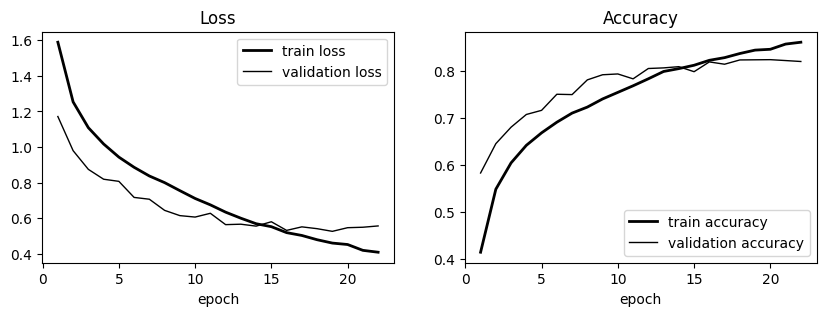

In [20]:
# 학습 결과 시각화
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(range(1, epoch + 2), train_losses, label="train loss",
         color="black", linewidth=2)
plt.plot(range(1, epoch + 2), valid_losses, label="validation loss",
         color="black", linewidth=1)
plt.xticks(range(0, (epoch + 2), 5))
plt.title("Loss")
plt.xlabel("epoch")
plt.legend(loc="best")

plt.subplot(1, 2, 2)
plt.plot(range(1, epoch + 2), train_accs, label="train accuracy",
         color="black", linewidth=2)
plt.plot(range(1, epoch + 2), valid_accs, label="validation accuracy",
         color="black", linewidth=1)
plt.xticks(range(0, (epoch + 2), 5))
plt.title("Accuracy")
plt.xlabel("epoch")
plt.legend(loc="best")

plt.show()

In [21]:
# 모델 평가
model.eval()   # 평가 모드

correct = 0
actual = []
predicted = []

with torch.no_grad():   # 평가할 때에는 자동 미분하지 않음
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)   # 출력 계산
        predict = outputs.argmax(dim=1)   # 예측
        correct += (predict == labels).sum().item()   # 정확한 예측

        actual.extend(labels.cpu().numpy())   # 실제값 리스트 생성
        predicted.extend(predict.cpu().numpy())   # 실제값 리스트 생성

test_acc = 100 * correct / len(test_loader.dataset)   # 정확도 계산

print(f"Accuracy: {test_acc:.2f}%")

Accuracy: 81.01%


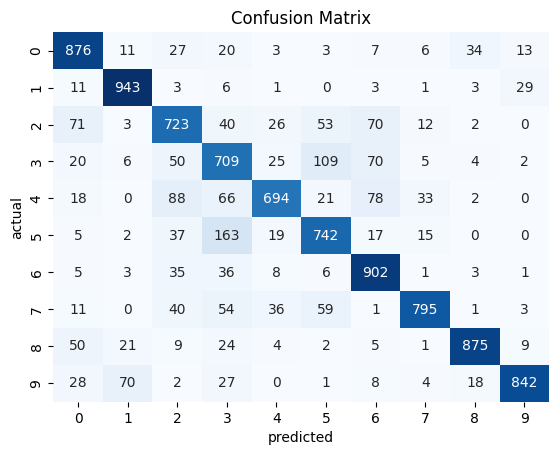

In [22]:
# 혼동 행렬 시각화
cm = confusion_matrix(actual, predicted)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("predicted")
plt.ylabel("actual")

plt.show()

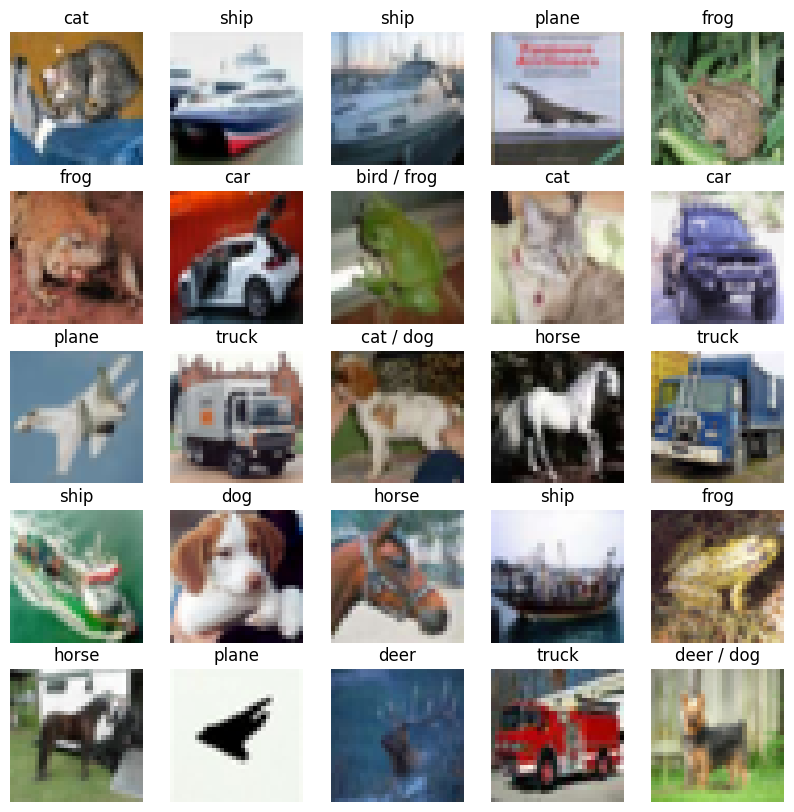

In [26]:
# 모델 예측 결과 시각화
model.eval()   # 평가 모드

images, labels = next(iter(test_loader))
images = images[:25].to(device)
labels = labels[:25].to(device)

with torch.no_grad():   # 예측할 때에는 자동 미분하지 않음
    outputs = model(images)
    predict = outputs.argmax(dim=1)   # 예측

mean = torch.tensor([0.49, 0.48, 0.45]).view(3, 1, 1)
std = torch.tensor([0.25, 0.24, 0.26]).view(3, 1, 1)

plt.figure(figsize=(10, 10))

for i in range(25):
    img = images[i].cpu() * std + mean   # 역정규화
    img = img.permute(1, 2, 0)   # (H,W,C)

    plt.subplot(5, 5, i+1)
    plt.imshow(img)
    if predict[i] != labels[i]:
        plt.title(f"{class_names[predict[i].item()]} / {class_names[labels[i].item()]}")
    else:
        plt.title(class_names[predict[i].item()])
    plt.axis("off")

plt.show()

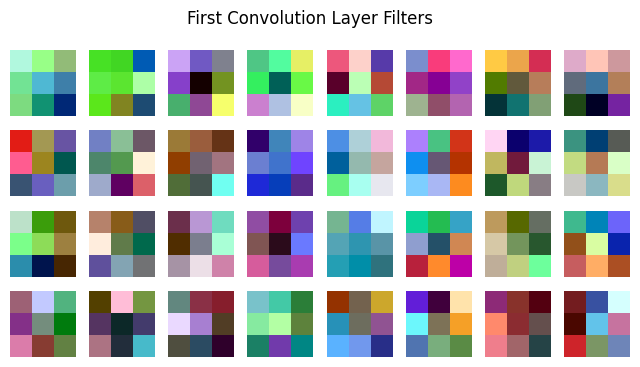

In [ ]:
# 첫번째 컨볼루션 계층의 필터 시각화
first_conv = model.feature_extractor[0]
filters = first_conv.weight.data.cpu()

fig, axes = plt.subplots(4, 8, figsize=(8, 4))
fig.suptitle("First Convolution Layer Filters")

for i, ax in enumerate(axes.flat):
    f = filters[i]
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    ax.imshow(f.permute(1, 2, 0))   # (H, W, C)
    ax.axis("off")

plt.show()

In [ ]:
# 특징맵 생성 함수 정의
layers = {"0": "block1_conv1", "7": "block2_conv1", "14": "block3_conv",
          "17": "block3_maxpool"}

def get_features(x):
    features = {}
    for name, layer in model.feature_extractor._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
    return features

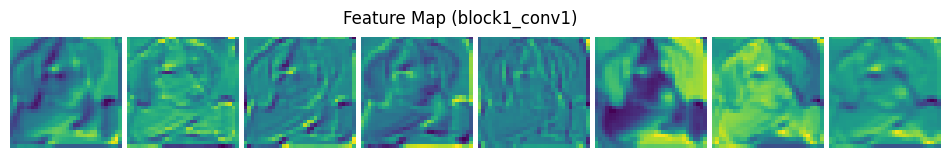

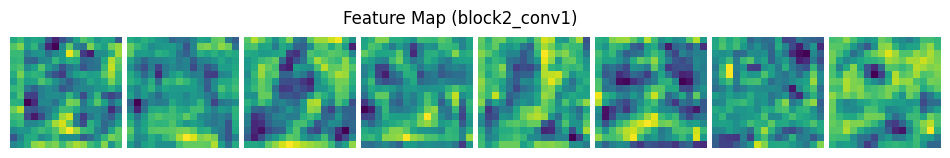

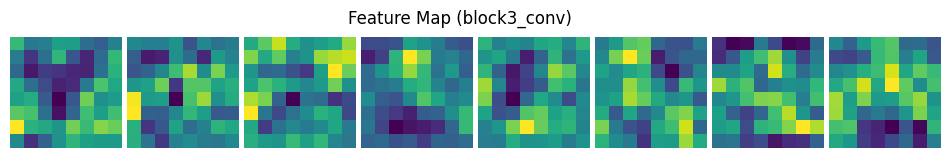

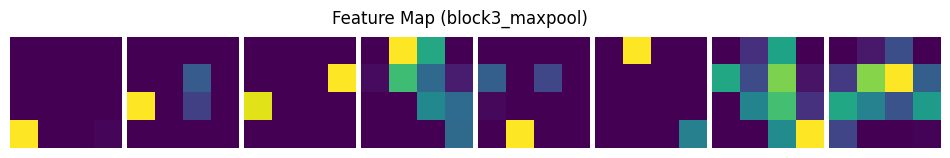

In [ ]:
# 특징맵 시각화
image, _ = test_dataset[16]   # 강아지 이미지
x = image.unsqueeze(0).to(device)

model.eval()   # 평가 모드

with torch.no_grad():   # 자동 미분하지 않음
    features = get_features(x)

max_channels = 8

for layer_idx, (name, fmap) in enumerate(features.items()):
    fmap = fmap[0].detach().cpu()  # (C, H, W)
    num_channels = fmap.shape[0]
    n = min(max_channels, num_channels)

    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 1.5))
    plt.suptitle(f"Feature Map ({name})", y=1.05)
    plt.subplots_adjust(wspace=0.05, hspace=0)

    for i in range(n):
        img = fmap[i]
        img = (img - img.min()) / (img.max() - img.min() + 1e-5)

        axes[i].imshow(img, cmap="viridis")
        axes[i].axis("off")

    plt.show()

https://www.kaggle.com/datasets/birajsth/cats-and-dogs-filtered?utm_source=chatgpt.com

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 셋업
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

In [ ]:
# 디바이스 지정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# cats-and-dogs-filtered 학습 데이터의 RGB 평균/표준편차 확인
transform = transforms.Compose([transforms.Resize((224, 224)),
                                transforms.ToTensor()])
dataset = ImageFolder(
    root='/content/drive/MyDrive/Datasets/cats_and_dogs_filtered/train',
    transform=transform)

all_images = torch.stack(
    [dataset[i][0] for i in range(len(dataset))], dim=0)
mean = all_images.mean(dim=[0, 2, 3])
std = all_images.std(dim=[0, 2, 3])

print(f"mean: {mean} \n std: {std}")

mean: tensor([0.4925, 0.4597, 0.4198]) 
 std: tensor([0.2615, 0.2550, 0.2588])


In [ ]:
# 데이터셋 생성/전처리
train_dir = "/content/drive/MyDrive/Datasets/cats_and_dogs_filtered/train"
test_dir = "/content/drive/MyDrive/Datasets/cats_and_dogs_filtered/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),   # 이미지 크기 조정
    transforms.RandomHorizontalFlip(),   # 수평 뒤집기
    transforms.RandomRotation(10),   # 회전
    transforms.ToTensor(),   # 텐서 변환
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])   # 정규화
])

train_dataset = ImageFolder(root=train_dir, transform=transform)
test_dataset = ImageFolder(root=test_dir, transform=transform)

print(len(train_dataset))   # 학습 데이터 확인
print(train_dataset.classes)
print(len(test_dataset))   # 테스트 데이터 확인
print(test_dataset.classes)

2146
['cats', 'dogs']
1000
['cats', 'dogs']


In [ ]:
# 소규모 데이터셋 생성
train_index = list(range(len(train_dataset)))
random.shuffle(train_index)
train_subset = Subset(train_dataset, train_index[:len(train_dataset)//10])

test_index = list(range(len(test_dataset)))
random.shuffle(test_index)
test_subset = Subset(test_dataset, test_index[:len(test_dataset)//10])

print(len(train_subset))   # 샘플 수 확인
print(len(test_subset))

214
100


In [ ]:
# 데이터 로더 생성
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)

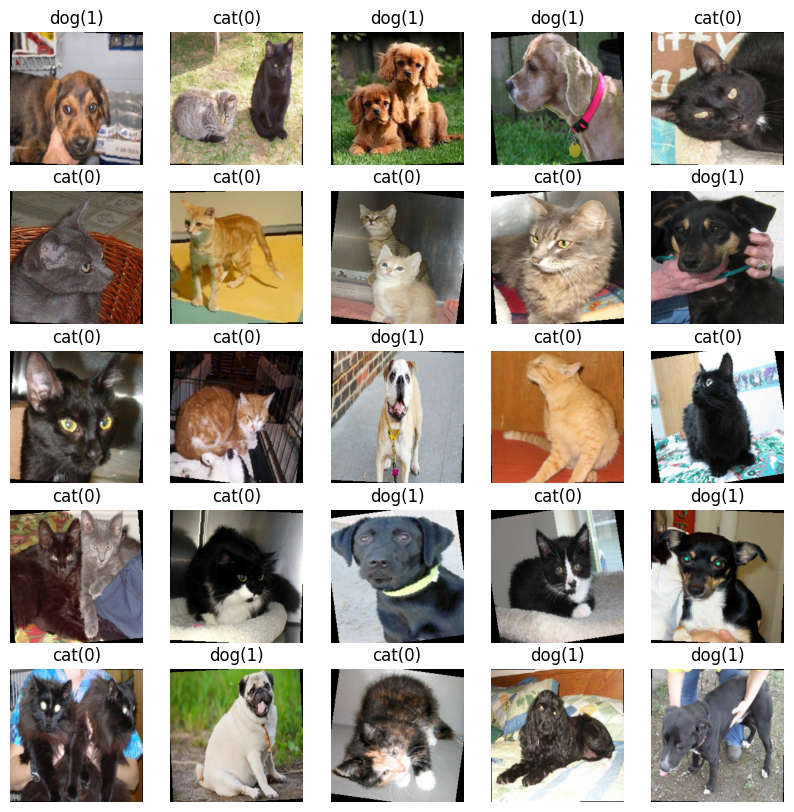

In [ ]:
# 학습 데이터 시각화
class_names = ["cat", "dog"]

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 10))

for i in range(25):
    image = images[i]
    label = int(labels[i])

    image = image * std + mean
    image = torch.clamp(image, 0, 1)   # 크기 조정(0 ~ 1)

    plt.subplot(5, 5, i + 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(f"{class_names[label]}({label})")
    plt.axis("off")

plt.show()

In [ ]:
# 모델 생성(사전 학습 모델 활용)
pre_trained_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]


In [ ]:
# 사전 학습 모델의 각 계층 확인
for name, param in pre_trained_model.named_parameters():
    print(name, param.shape)

conv1.weight torch.Size([64, 3, 7, 7])
bn1.weight torch.Size([64])
bn1.bias torch.Size([64])
layer1.0.conv1.weight torch.Size([64, 64, 3, 3])
layer1.0.bn1.weight torch.Size([64])
layer1.0.bn1.bias torch.Size([64])
layer1.0.conv2.weight torch.Size([64, 64, 3, 3])
layer1.0.bn2.weight torch.Size([64])
layer1.0.bn2.bias torch.Size([64])
layer1.1.conv1.weight torch.Size([64, 64, 3, 3])
layer1.1.bn1.weight torch.Size([64])
layer1.1.bn1.bias torch.Size([64])
layer1.1.conv2.weight torch.Size([64, 64, 3, 3])
layer1.1.bn2.weight torch.Size([64])
layer1.1.bn2.bias torch.Size([64])
layer2.0.conv1.weight torch.Size([128, 64, 3, 3])
layer2.0.bn1.weight torch.Size([128])
layer2.0.bn1.bias torch.Size([128])
layer2.0.conv2.weight torch.Size([128, 128, 3, 3])
layer2.0.bn2.weight torch.Size([128])
layer2.0.bn2.bias torch.Size([128])
layer2.0.downsample.0.weight torch.Size([128, 64, 1, 1])
layer2.0.downsample.1.weight torch.Size([128])
layer2.0.downsample.1.bias torch.Size([128])
layer2.1.conv1.weight tor

In [ ]:
# 사전 학습 모델의 파라미터 동결(분류기 제외)
for name, parameter in pre_trained_model.named_parameters():
    parameter.requires_grad = False

    if "layer4.1" in name:
        break

In [ ]:
# 분류기 변경
num_features = pre_trained_model.fc.in_features

pre_trained_model.fc = nn.Sequential(
    nn.Linear(num_features, 128),   # 은닉층 뉴런 128개
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 2)   # 출력층 뉴런 2개
)

In [ ]:
# 모델 생성
model = pre_trained_model.to(device)

In [ ]:
# 하이퍼파라미터 설정
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [ ]:
# 학습 함수 정의
def train_step(model, optimizer, loss_fn, train_loader, device):
    model.train()   # 학습 모드

    train_loss = 0
    correct = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)   # 출력 계산
        loss = loss_fn(outputs, labels)   # 손실 계산

        optimizer.zero_grad()   # 그레디언트 초기화
        loss.backward()   # 역전파
        optimizer.step()   # 최적화 수행

        train_loss += loss.item() * images.size(0)

        predict = outputs.argmax(dim=1)   # 예측
        correct += (predict == labels).sum().item()   # 정확한 예측

    train_loss /= len(train_loader.dataset)   # 학습 손실
    train_acc = correct / len(train_loader.dataset)   # 학습 정확도

    return train_loss, train_acc

In [ ]:
# 모델 학습
epochs = 10   # 반복 횟수
train_losses = []   # 학습 손실 리스트
train_accs = []   # 학습 정확도 리스트

for epoch in range(epochs):
    train_loss, train_acc = train_step(model, optimizer, loss_fn,
                                       train_loader, device)
    train_losses.append(train_loss)   # 학습 손실 저장(학습 결과 시각화용)
    train_accs.append(train_acc)   # 학습 정확도 저장(학습 결과 시각화용)

    print(f"Epoch {epoch + 1} / {epochs} \n"
          f" - loss: {train_loss:.4f}  - accuracy: {train_acc:.4f}")

Epoch 1 / 10 
 - loss: 0.5273  - accuracy: 0.7477
Epoch 2 / 10 
 - loss: 0.3675  - accuracy: 0.8318
Epoch 3 / 10 
 - loss: 0.2700  - accuracy: 0.9065
Epoch 4 / 10 
 - loss: 0.2411  - accuracy: 0.9159
Epoch 5 / 10 
 - loss: 0.1166  - accuracy: 0.9673
Epoch 6 / 10 
 - loss: 0.1955  - accuracy: 0.9159
Epoch 7 / 10 
 - loss: 0.0971  - accuracy: 0.9673
Epoch 8 / 10 
 - loss: 0.1269  - accuracy: 0.9393
Epoch 9 / 10 
 - loss: 0.1528  - accuracy: 0.9346
Epoch 10 / 10 
 - loss: 0.0755  - accuracy: 0.9673


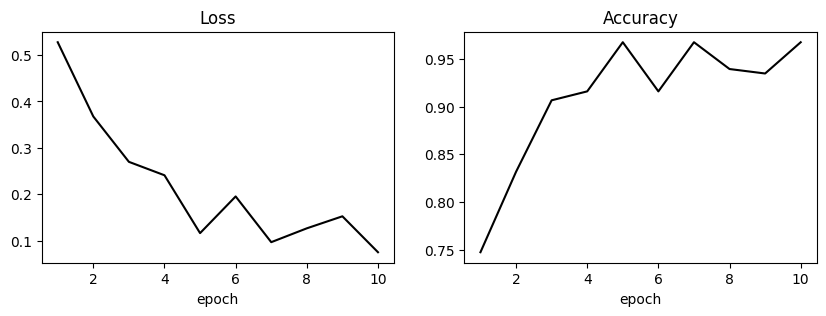

In [ ]:
# 학습 결과 시각화
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses,  color='black')
plt.xlabel("epoch")
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accs,  color='black')
plt.xlabel("epoch")
plt.title("Accuracy")

plt.show()

In [ ]:
# 모델 평가
model.eval()   # 평가 모드

correct = 0

with torch.no_grad():   # 평가할 때에는 자동 미분하지 않음
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)   # 출력 계산
        predict = outputs.argmax(dim=1)   # 예측

        correct += (predict == labels).sum().item()   # 정확한 예측

test_acc = 100 * correct / len(test_loader.dataset)   # 정확도 계산

print(f"Accuracy: {test_acc:.2f}%")

Accuracy: 95.00%


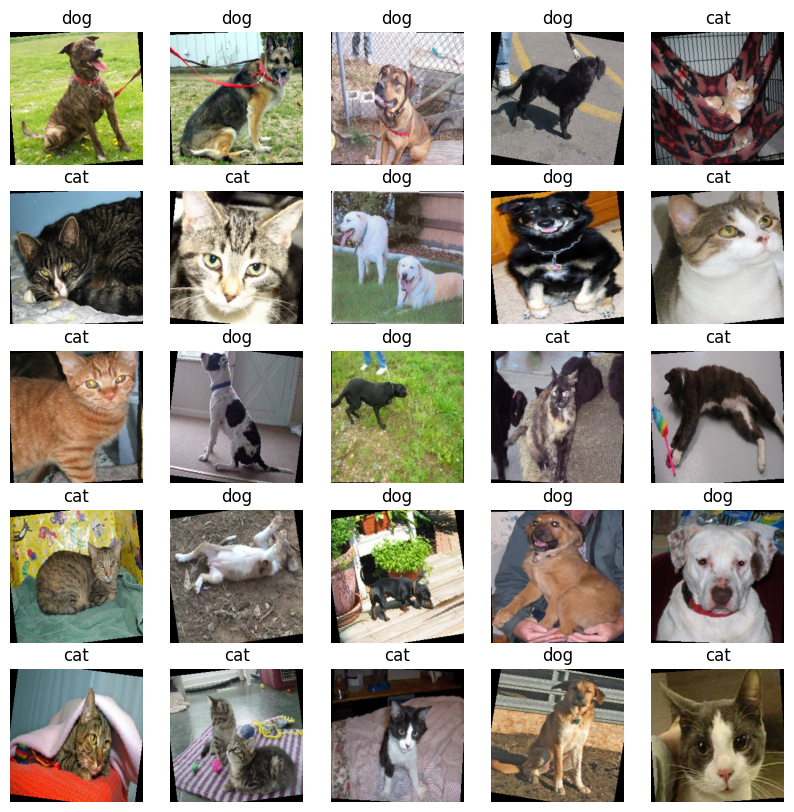

In [ ]:
# 모델 예측 결과 시각화
model.eval()   # 평가 모드

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():   # 예측할 때에는 자동 미분하지 않음
    outputs = model(images)
    predict = outputs.argmax(dim=1)   # 예측

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

plt.figure(figsize=(10 ,10))

for i in range(25):
    img = images[i].cpu() * std + mean   # 역정규화
    img = img.permute(1, 2, 0)   # (H,W,C)

    plt.subplot(5, 5, i+1)
    plt.imshow(img)
    if predict[i] != labels[i]:
        plt.title(f"{class_names[predict[i].item()]}"
                  f" / {class_names[labels[i].item()]}")
    else:
        plt.title(class_names[predict[i].item()])
    plt.axis("off")

plt.show()

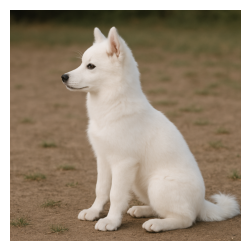

predict: dog (score: 0.9920)


In [ ]:
# 실제 입력 예측
model.eval()   # 평가 모드

file_path = "/content/drive/MyDrive/Datasets/강아지 사진.png"

image = Image.open(file_path).convert("RGB")

plt.figure(figsize=(3, 3))
plt.imshow(image)
plt.axis("off")

plt.show()

image = transform(image).unsqueeze(0)
image = image.to(device)

with torch.no_grad():
    outputs = model(image)
    outputs = torch.softmax(outputs, dim=1)
    predict = torch.max(outputs, 1)
    predicted_class = predict.indices.item()
    score = predict.values.item()

    print(f"predict: {class_names[predicted_class]}"
          f" (score: {score:.4f})")